# CECS 456-02: HW8
**Due date is 05/08/2025 at 11:59 pm**
**How to submit: Online in Canvas**

For programming homework, please submit your ipynb code and also put your results into
the pdf file you submit. You can type your solution for part 2 or turn in the scan file of your
solutions.

## HW8-1: Clustering

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min

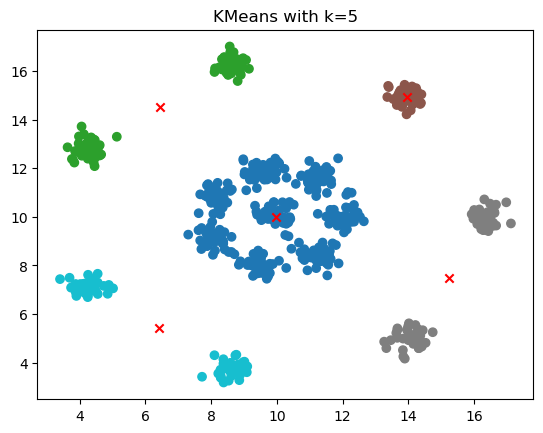

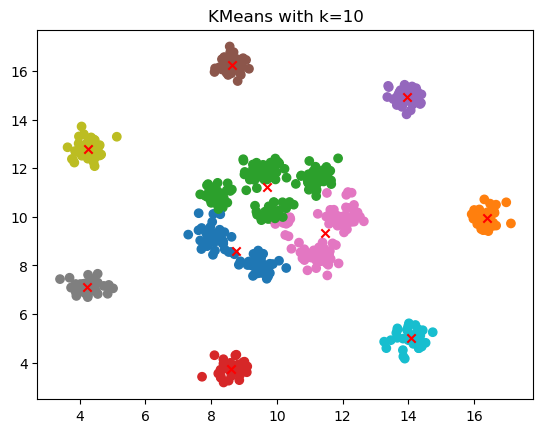

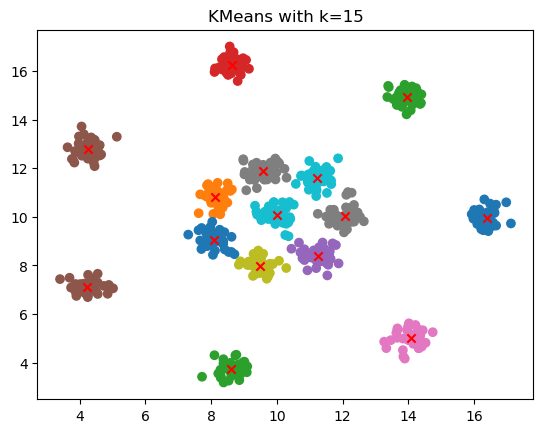

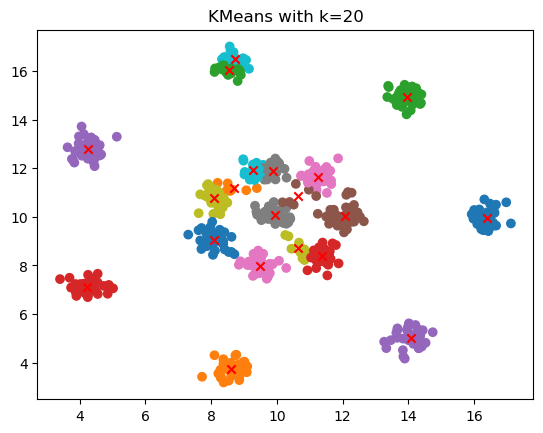

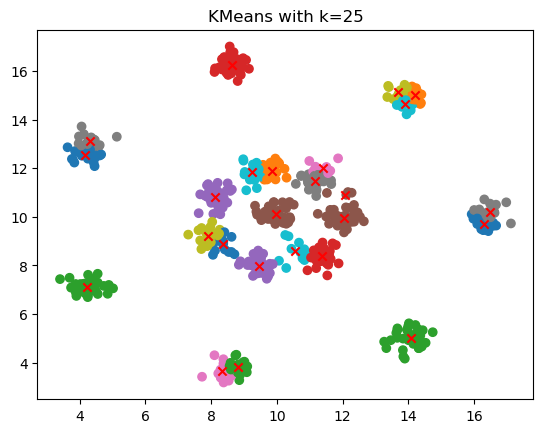

k = 5: Iterations=15, SSE=3109.38881175
k = 10: Iterations=5, SSE=507.75497845292466
k = 15: Iterations=7, SSE=108.61904081338335
k = 20: Iterations=6, SSE=96.20045100189353
k = 25: Iterations=7, SSE=80.76296563454325


In [4]:
# Load data
data = np.loadtxt("SynData1.txt")

# List of k values
k_values = [5, 10, 15, 20, 25]
sse_list = []
iteration_list = []

for k in k_values:
    k_means = KMeans(n_clusters = k, random_state  = 42)
    k_means.fit(data)
    sse = k_means.inertia_ # SSE
    iterations = k_means.n_iter_

    sse_list.append(sse)
    iteration_list.append(iterations)

    # Plotting
    plt.figure()
    plt.scatter(data[:, 0], data[:, 1], c=k_means.labels_, cmap='tab10')
    plt.scatter(k_means.cluster_centers_[:, 0], k_means.cluster_centers_[:, 1], color='red', marker='x')
    plt.title(f'KMeans with k={k}')
    plt.show()

# Print summary
for i, k in enumerate(k_values):
    print(f'k = {k}: Iterations={iteration_list[i]}, SSE={sse_list[i]}')

## HW8-2: Hierarchical Clustering 

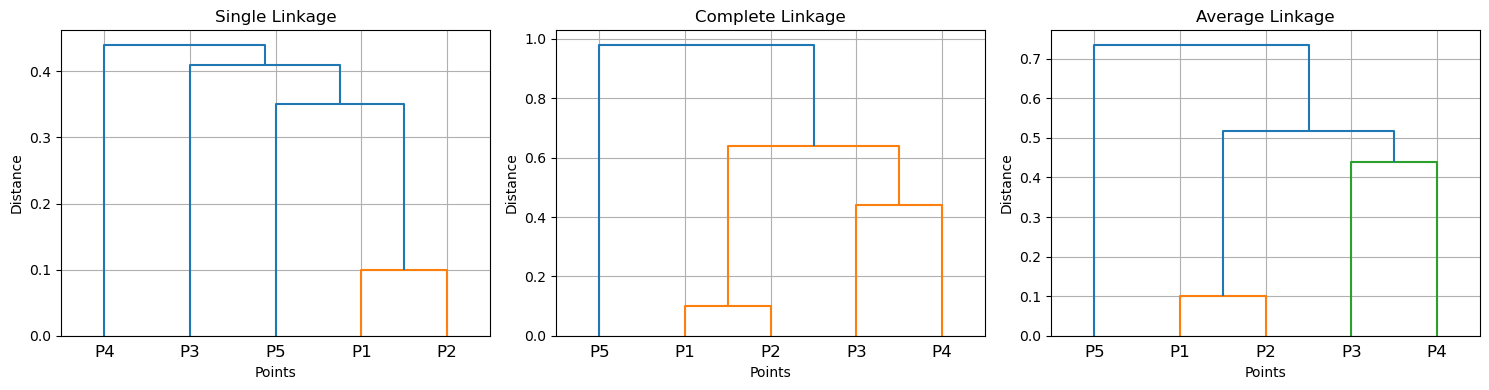

In [6]:
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt
from scipy.spatial.distance import squareform

# Replace this with your actual distance matrix
distance_matrix = np.array([
    [0.00, 0.10, 0.41, 0.55, 0.35],
    [0.10, 0.00, 0.64, 0.47, 0.98],
    [0.41, 0.64, 0.00, 0.44, 0.85],
    [0.55, 0.47, 0.44, 0.00, 0.76],
    [0.35, 0.98, 0.85, 0.76, 0.00]
])

# Convert to condensed distance matrix (upper triangle)
condensed_dist = squareform(distance_matrix)


# Define linkage methods and titles
methods = ['single', 'complete', 'average'] # These are the valid method names that scipy.cluster.hierarchy.linkage() accepts
titles = ['Single Linkage', 'Complete Linkage', 'Average Linkage']

# Plot all dendrograms in one row
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

for i, method in enumerate(methods):
    Z = linkage(condensed_dist, method=method)
    dendrogram(Z, labels=['P1', 'P2', 'P3', 'P4', 'P5'], ax=axs[i])
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Points")
    axs[i].set_ylabel("Distance")
    axs[i].grid(True)

plt.tight_layout()
plt.show()

## HW8-3: DBScan with Shape Sets


 Processing Aggregation.txt:
✔ Found match: eps= 0.2, clusters= 7


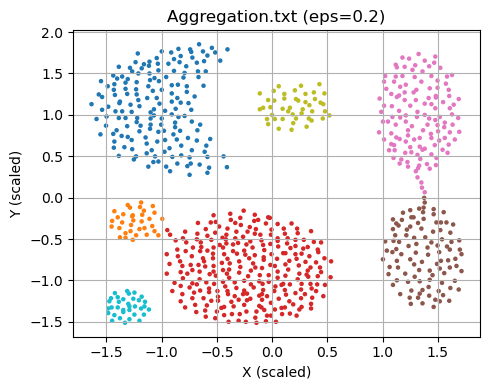


 Processing Compound.txt:
✔ Found match: eps= 0.35, clusters= 6


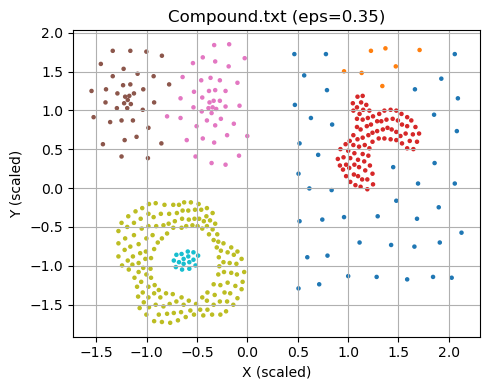


 Processing D31.txt:
✘ No exact match found for known_k = 31


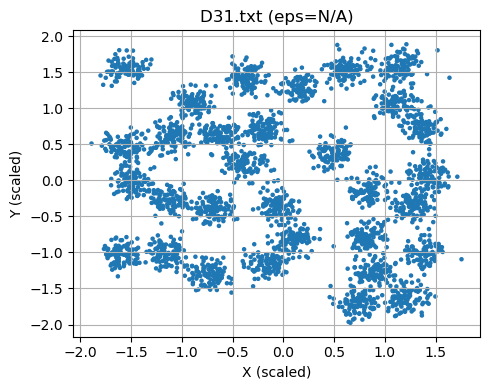


 Processing Pathbased.txt:
✔ Found match: eps= 0.35, clusters= 3


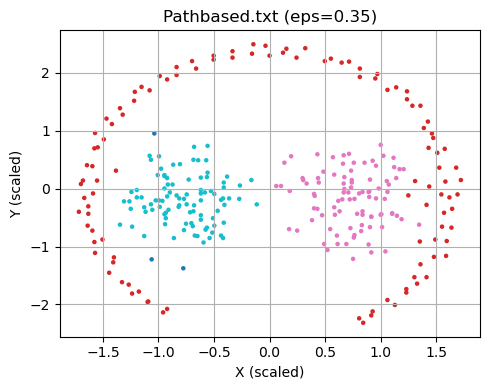


 Processing Spiral.txt:
✔ Found match: eps= 0.3, clusters= 3


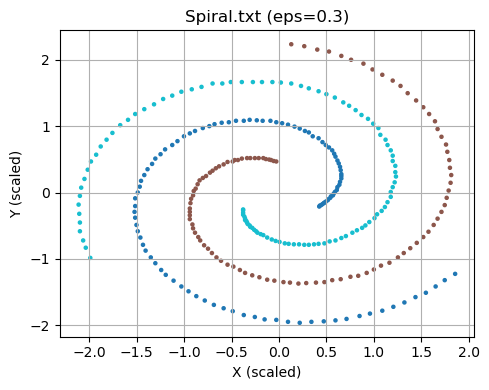


 Processing R15.txt:
✔ Found match: eps= 0.2, clusters= 15


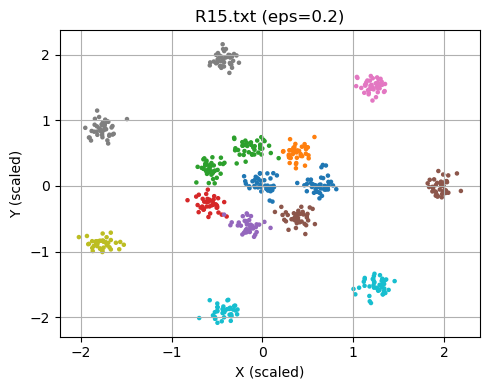


 Processing Jain.txt:
✔ Found match: eps= 0.35, clusters= 2


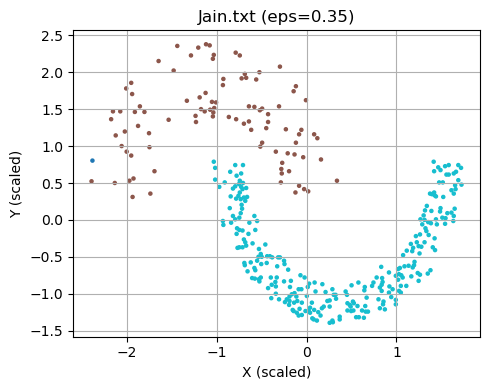


 Processing Flame.txt:
✔ Found match: eps= 0.3, clusters= 2


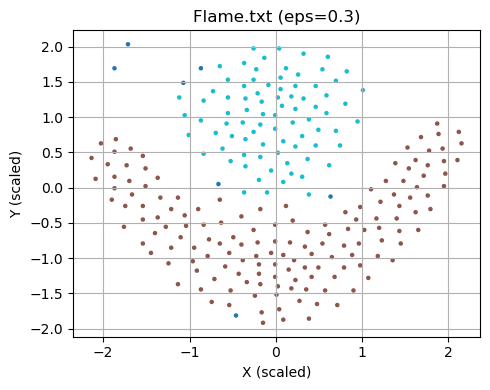


=== Summary ===
Aggregation.txt | Best eps: 0.2 | Clusters matched: 7
Compound.txt    | Best eps: 0.35 | Clusters matched: 6
D31.txt         | Best eps: None | Clusters matched: None
Pathbased.txt   | Best eps: 0.35 | Clusters matched: 3
Spiral.txt      | Best eps: 0.3 | Clusters matched: 3
R15.txt         | Best eps: 0.2 | Clusters matched: 15
Jain.txt        | Best eps: 0.35 | Clusters matched: 2
Flame.txt       | Best eps: 0.3 | Clusters matched: 2


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# File names
datasets = [
    "Aggregation.txt", "Compound.txt", "D31.txt", "Pathbased.txt",
    "Spiral.txt", "R15.txt", "Jain.txt", "Flame.txt"
]
known_k = [7, 6, 31, 3, 3, 15, 2, 2]  # Expected number of clusters

# DBSCAN parameter grid
eps_values = np.arange(0.2, 1.05, 0.05)  # Adjust range if needed
min_samples = 5

# Store results
results = []

# Loop through each dataset
for i, filename in enumerate(datasets):
    print(f"\n Processing {filename}:")
    data = np.loadtxt(filename)
    data_scaled = StandardScaler().fit_transform(data)

    best_match = None
    best_eps = None
    best_labels = None

    for eps in eps_values:
        db = DBSCAN(eps=eps, min_samples=min_samples).fit(data_scaled)
        labels = db.labels_
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        # If the number of clusters matches the expected, record it
        if n_clusters == known_k[i]:
            best_match = n_clusters
            best_eps = eps
            best_labels = labels
            break  # Stop at first match

    if best_match is not None:
        print(f"✔ Found match: eps= {best_eps}, clusters= {best_match}")
    else:
        print("✘ No exact match found for known_k =", known_k[i])
        best_eps = None
        best_labels = db.labels_

    results.append((filename, best_eps, best_match))

    # Plot result
    plt.figure(figsize=(5, 4))
    plt.scatter(data_scaled[:, 0], data_scaled[:, 1], c=best_labels, cmap='tab10', s=5)
    title = f"{filename} (eps={best_eps if best_eps else 'N/A'})"
    plt.title(title)
    plt.xlabel("X (scaled)")
    plt.ylabel("Y (scaled)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Print summary
print("\n=== Summary ===")
for fname, eps, match in results:
    print(f"{fname:<15} | Best eps: {eps} | Clusters matched: {match}")